# 4A - Ciclo ENSO em 4 fases: genese, crescimento/acoplamento, pico e decaimento

**Pergunta especifica.** Como separar, de forma logica e estatisticamente coerente, as 4 fases do ciclo ENSO - I. Genese, II. Crescimento/acoplamento, III. Pico, IV. Decaimento - tanto para El Nino quanto para La Nina, na base local OISST? Quanto dura cada fase, por tipo e por classe de intensidade?

**Metodologia.** Eventos pelo criterio NOAA/ONI local simetrico: media movel de 3 meses da SSTA Nino 3.4 >= +0,5 C (El Nino) ou <= -0,5 C (La Nina) por >= 5 estacoes moveis sobrepostas; intensidade pelo pico de |ONI|. Fases por evento, com criterio estatistico explicito: **pico** = plateau com |ONI| >= 90% do maximo do evento; **crescimento** = do onset ate o plateau; **decaimento** = do plateau ate o fim; **genese** = 26 semanas pre-onset (janela onde 3C/3H mostram a organizacao dos precursores de recarga), apenas sobre semanas neutras. O rotulo e projetado na grade semanal W-SUN.

**Saidas.** `phase4A_eventos_enso.csv`, `phase4A_fases_semanais.csv`, `phase4A_fases_resumo.csv`, `phase4A_duracao_fases_por_evento.csv`, `phase4A_ciclo_enso.png`, `phase4A_duracao_fases.png`.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase4_utils as u

oni = u.load_oni_monthly()
ev = u.enso_events(oni)
u.save_table(ev, 'phase4A_eventos_enso.csv', index=False)
print(f"Eventos: {int((ev.tipo=='el_nino').sum())} El Nino, {int((ev.tipo=='la_nina').sum())} La Nina")
print(ev[['event_id','tipo','classe','onset','pico','fim','duracao_estacoes','oni_pico_c']].to_string(index=False))

[tabela] data/processed/parquet/statistics/phase4A_eventos_enso.csv
Eventos: 12 El Nino, 11 La Nina
         event_id    tipo      classe      onset       pico        fim  duracao_estacoes  oni_pico_c
el_nino_1982_1983 el_nino muito_forte 1982-07-01 1983-01-01 1983-05-31                11       2.120
la_nina_1983_1984 la_nina    moderada 1983-09-01 1983-11-01 1984-02-29                 6      -1.210
la_nina_1984_1986 la_nina    moderada 1984-04-01 1984-12-01 1986-04-30                25      -1.392
el_nino_1986_1988 el_nino    moderado 1986-10-01 1987-08-01 1988-01-31                16       1.211
la_nina_1988_1989 la_nina muito_forte 1988-04-01 1988-11-01 1989-10-31                19      -2.125
el_nino_1991_1992 el_nino       forte 1991-09-01 1992-01-01 1992-06-30                10       1.625
el_nino_1994_1995 el_nino       fraco 1994-10-01 1994-12-01 1995-02-28                 5       0.968
la_nina_1995_1996 la_nina       fraca 1995-09-01 1995-11-01 1996-04-30                 8    

In [2]:
w = u.load_pacific_weekly()
fases = u.enso_phase_weekly(oni, ev, w.index)
u.save_table(fases, 'phase4A_fases_semanais.csv')
resumo = (fases.groupby(['tipo','fase']).size().rename('semanas').reset_index())
resumo['fracao_%'] = (100*resumo['semanas']/len(fases)).round(1)
u.save_table(resumo, 'phase4A_fases_resumo.csv', index=False)
print(resumo.to_string(index=False))

# duracao de cada fase por evento (semanas)
rows = []
for _, e in ev.iterrows():
    sub = fases[fases['event_id'] == e.event_id]
    d = sub.groupby('fase').size()
    rows.append({'event_id': e.event_id, 'tipo': e.tipo, 'classe': e.classe,
                 'oni_pico_c': e.oni_pico_c,
                 **{f'{f}_sem': int(d.get(f, 0)) for f in u.FASE_ORDER}})
dur = pd.DataFrame(rows)
u.save_table(dur, 'phase4A_duracao_fases_por_evento.csv', index=False)
print(dur.to_string(index=False))

[tabela] data/processed/parquet/statistics/phase4A_fases_semanais.csv
[tabela] data/processed/parquet/statistics/phase4A_fases_resumo.csv
   tipo        fase  semanas  fracao_%
el_nino crescimento      236       9.9
el_nino  decaimento      128       5.4
el_nino      genese      295      12.4
el_nino        pico      162       6.8
la_nina crescimento      162       6.8
la_nina  decaimento      272      11.5
la_nina      genese      183       7.7
la_nina        pico      217       9.1
 neutro      neutro      717      30.2
[tabela] data/processed/parquet/statistics/phase4A_duracao_fases_por_evento.csv
         event_id    tipo      classe  oni_pico_c  genese_sem  crescimento_sem  pico_sem  decaimento_sem
el_nino_1982_1983 el_nino muito_forte       2.120          26               18        13              17
la_nina_1983_1984 la_nina    moderada      -1.210          13                9         8               9
la_nina_1984_1986 la_nina    moderada      -1.392           4               3

[figura] data/processed/figures/fase4/phase4A_ciclo_enso.png


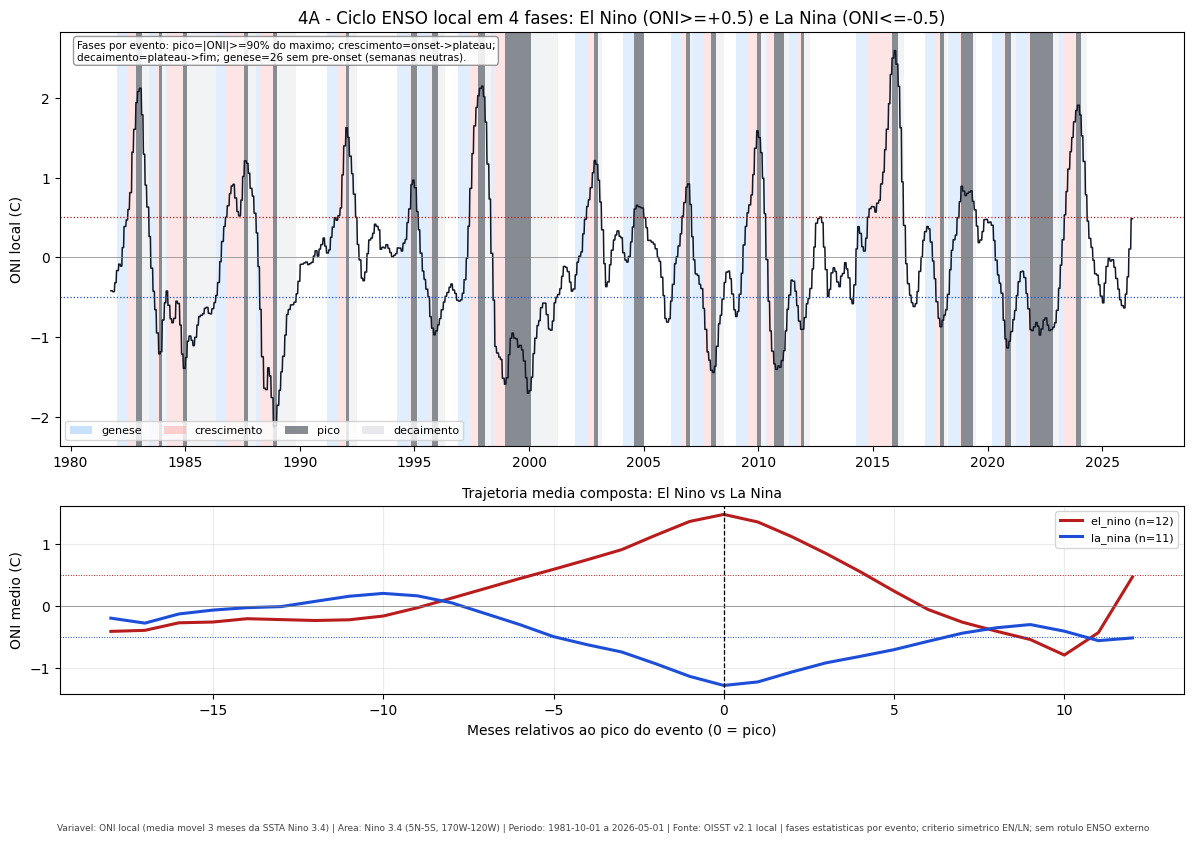

In [3]:
oni_w = oni.reindex(pd.date_range(oni.index.min(), oni.index.max(), freq='W-SUN'), method='ffill')
fig, axes = plt.subplots(2, 1, figsize=(14.5, 8.6), gridspec_kw={'height_ratios':[2.2, 1]})
ax = axes[0]
for i in range(len(fases)-1):
    f, tp = fases['fase'].iloc[i], fases['tipo'].iloc[i]
    if f == 'neutro':
        continue
    cor = u.FASE_CORES[f]
    ax.axvspan(fases.index[i], fases.index[i+1], color=cor, alpha=.28 if f!='pico' else .5, lw=0)
ax.plot(oni_w.index, oni_w.values, color='#111827', lw=1.1)
ax.axhline(0.5, color='#b91c1c', ls=':', lw=.9); ax.axhline(-0.5, color='#1d4ed8', ls=':', lw=.9)
ax.axhline(0, color='0.5', lw=.5)
ax.set_ylabel('ONI local (C)')
ax.set_title('4A - Ciclo ENSO local em 4 fases: El Nino (ONI>=+0.5) e La Nina (ONI<=-0.5)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(fc=u.FASE_CORES[f], alpha=.5, label=f) for f in u.FASE_ORDER], fontsize=8, ncol=4, loc='lower left')
u.add_note(ax, 'Fases por evento: pico=|ONI|>=90% do maximo; crescimento=onset->plateau;\ndecaimento=plateau->fim; genese=26 sem pre-onset (semanas neutras).', loc='upper left')
ax2 = axes[1]
for j, tipo in enumerate(['el_nino','la_nina']):
    sub = ev[ev.tipo==tipo]
    comps = []
    for _, e in sub.iterrows():
        seg = oni.loc[pd.to_datetime(e.onset)-pd.DateOffset(months=12):pd.to_datetime(e.fim)+pd.DateOffset(months=6)]
        rel = ((seg.index - pd.to_datetime(e.pico)).days/30.44).round().astype(int)
        comps.append(pd.Series(seg.values, index=rel).groupby(level=0).mean().reindex(range(-18,13)))
    m = pd.DataFrame(comps).mean()
    cor = '#b91c1c' if tipo=='el_nino' else '#1d4ed8'
    ax2.plot(m.index, m.values, color=cor, lw=2.2, label=f"{tipo} (n={len(sub)})")
ax2.axvline(0, color='k', ls='--', lw=.9); ax2.axhline(0, color='0.5', lw=.5)
ax2.axhline(0.5, color='#b91c1c', ls=':', lw=.7); ax2.axhline(-0.5, color='#1d4ed8', ls=':', lw=.7)
ax2.set_xlabel('Meses relativos ao pico do evento (0 = pico)')
ax2.set_ylabel('ONI medio (C)')
ax2.legend(fontsize=8); ax2.grid(alpha=.25)
ax2.set_title('Trajetoria media composta: El Nino vs La Nina', fontsize=10)
u.stamp_caption(fig, variavel='ONI local (media movel 3 meses da SSTA Nino 3.4)', area='Nino 3.4 (5N-5S, 170W-120W)', periodo=f'{oni.dropna().index.min().date()} a {oni.dropna().index.max().date()}', fonte='OISST v2.1 local', extra='fases estatisticas por evento; criterio simetrico EN/LN; sem rotulo ENSO externo')
u.save_fig(fig, 'phase4A_ciclo_enso.png')
plt.show()

[figura] data/processed/figures/fase4/phase4A_duracao_fases.png


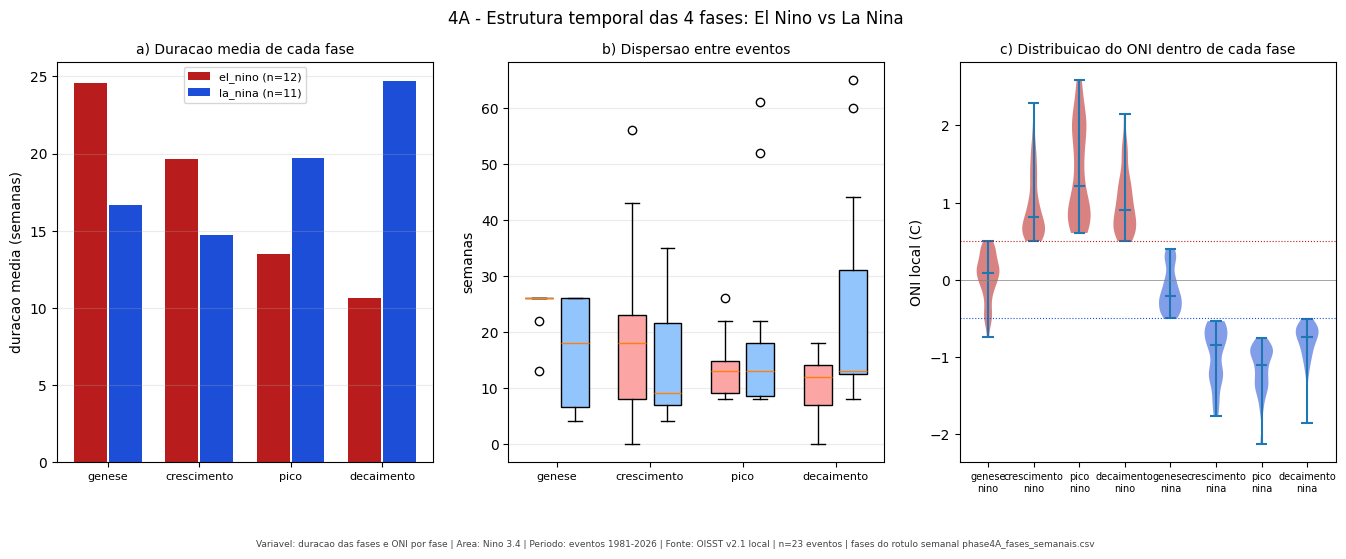

In [4]:
# Avaliacao expandida: quanto dura cada fase, por tipo e classe; e o ONI dentro de cada fase
cols = [f'{f}_sem' for f in u.FASE_ORDER]
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
med = dur.groupby('tipo')[cols].mean()
xx = np.arange(len(u.FASE_ORDER))
for k, (tipo, cor) in enumerate([('el_nino','#b91c1c'), ('la_nina','#1d4ed8')]):
    axes[0].bar(xx + (k-.5)*.38, med.loc[tipo, cols], width=.36, color=cor, label=f'{tipo} (n={int((dur.tipo==tipo).sum())})')
axes[0].set_xticks(xx); axes[0].set_xticklabels(u.FASE_ORDER, fontsize=8)
axes[0].set_ylabel('duracao media (semanas)')
axes[0].set_title('a) Duracao media de cada fase', fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=.25)

for k, tipo in enumerate(['el_nino','la_nina']):
    sub = dur[dur.tipo==tipo]
    bp = axes[1].boxplot([sub[c] for c in cols], positions=xx + (k-.5)*.38, widths=.3, patch_artist=True, manage_ticks=False)
    for b in bp['boxes']:
        b.set_facecolor('#fca5a5' if tipo=='el_nino' else '#93c5fd')
axes[1].set_xticks(xx); axes[1].set_xticklabels(u.FASE_ORDER, fontsize=8)
axes[1].set_title('b) Dispersao entre eventos', fontsize=10)
axes[1].set_ylabel('semanas'); axes[1].grid(axis='y', alpha=.25)

fases_on = fases.join(oni_w.rename('oni'))
dados, labels, cores = [], [], []
for tipo, cor in [('el_nino','#b91c1c'), ('la_nina','#1d4ed8')]:
    for f in u.FASE_ORDER:
        v = fases_on.loc[(fases_on.tipo==tipo) & (fases_on.fase==f), 'oni'].dropna()
        dados.append(v); labels.append(f'{f}\n{tipo.split("_")[1]}'); cores.append(cor)
vp = axes[2].violinplot(dados, showmedians=True)
for body, cor in zip(vp['bodies'], cores):
    body.set_facecolor(cor); body.set_alpha(.55)
axes[2].axhline(0.5, color='#b91c1c', ls=':', lw=.8); axes[2].axhline(-0.5, color='#1d4ed8', ls=':', lw=.8)
axes[2].axhline(0, color='0.5', lw=.5)
axes[2].set_xticks(range(1, len(labels)+1)); axes[2].set_xticklabels(labels, fontsize=7)
axes[2].set_ylabel('ONI local (C)')
axes[2].set_title('c) Distribuicao do ONI dentro de cada fase', fontsize=10)
fig.suptitle('4A - Estrutura temporal das 4 fases: El Nino vs La Nina')
u.stamp_caption(fig, variavel='duracao das fases e ONI por fase', area='Nino 3.4', periodo='eventos 1981-2026', fonte='OISST v2.1 local', n=f"{len(ev)} eventos", extra='fases do rotulo semanal phase4A_fases_semanais.csv')
u.save_fig(fig, 'phase4A_duracao_fases.png')
plt.show()

[figura] data/processed/figures/fase4/phase4A_plano_fase.png


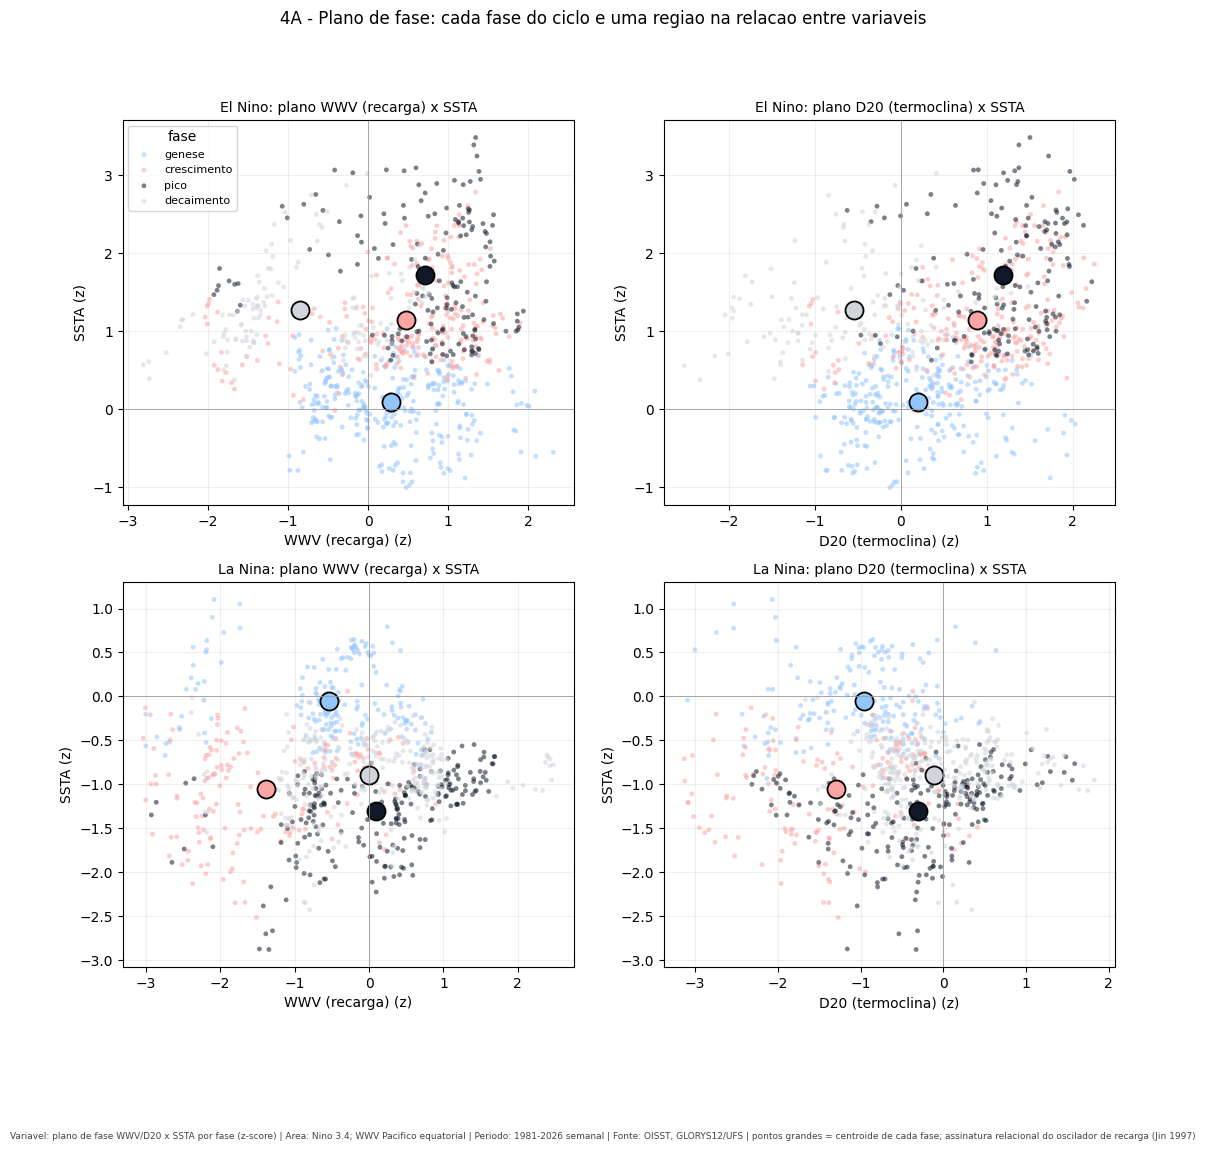

In [5]:
# Plano de fase: cada fase do ciclo como uma REGIAO na relacao entre duas variaveis (oscilador de recarga)
znino = (w['nino34_ssta'] - w['nino34_ssta'].mean())/w['nino34_ssta'].std()
pares_plano = [('wwv','nino34_ssta','WWV (recarga)','SSTA'), ('d20_m','nino34_ssta','D20 (termoclina)','SSTA')]
fig, axes = plt.subplots(2, 2, figsize=(12.8, 11))
for r, tipo in enumerate(['el_nino','la_nina']):
    m_t = fases['tipo'].eq(tipo)
    for c, (xa, ya, xl, yl) in enumerate(pares_plano):
        ax = axes[r, c]
        zx = (w[xa]-w[xa].mean())/w[xa].std(); zy = (w[ya]-w[ya].mean())/w[ya].std()
        for f in u.FASE_ORDER:
            mm = m_t & fases['fase'].eq(f)
            ax.scatter(zx[mm], zy[mm], s=12, color=u.FASE_CORES[f], alpha=.55, label=f, edgecolor='none')
            if mm.sum() > 5:
                ax.plot(zx[mm].mean(), zy[mm].mean(), 'o', ms=13, color=u.FASE_CORES[f], mec='k', mew=1.3)
        ax.axhline(0, color='0.6', lw=.6); ax.axvline(0, color='0.6', lw=.6)
        ax.set_xlabel(f'{xl} (z)'); ax.set_ylabel(f'{yl} (z)')
        ax.set_title(f'{"El Nino" if tipo=="el_nino" else "La Nina"}: plano {xl} x {yl}', fontsize=10)
        ax.grid(alpha=.2)
        if r==0 and c==0:
            ax.legend(fontsize=8, title='fase', loc='upper left')
fig.suptitle('4A - Plano de fase: cada fase do ciclo e uma regiao na relacao entre variaveis', y=0.98)
u.stamp_caption(fig, variavel='plano de fase WWV/D20 x SSTA por fase (z-score)', area='Nino 3.4; WWV Pacifico equatorial', periodo='1981-2026 semanal', fonte='OISST, GLORYS12/UFS', extra='pontos grandes = centroide de cada fase; assinatura relacional do oscilador de recarga (Jin 1997)')
u.save_fig(fig, 'phase4A_plano_fase.png')
plt.show()

**Leitura do 4A.** O ciclo ENSO local fica separado em 4 fases auditaveis por evento, com o mesmo criterio para El Nino e La Nina. O plateau de 90% evita que um unico mes defina o pico; a genese de 26 semanas e herdada do diagnostico fisico da Fase 3. A avaliacao expandida mostra a assimetria EN/LN: duracao tipica de cada fase, dispersao entre eventos e a distribuicao do ONI dentro de cada fase. O rotulo semanal `phase4A_fases_semanais.csv` condiciona o estudo de determinantes (4B) e o sinal pixel-a-pixel (4C).